# Pipeline Preditivo — Previsão de Falhas em Equipamentos Industriais
## Projeto Avaliativo | SENAI/SCTEC — IA para Análise Preditiva

**Autor:** Diogo Zoboli  
**Dataset:** manutencao_preditiva.csv
**Objetivo:** Construir um pipeline para prever falhas mecânicas em equipamentos industriais monitorados por sensores, comparando KNN e Árvore de Decisão com ajuste de hiperparâmetros e combate ao overfitting.

---
## Imports e Configuração Inicial

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# configs pra deixar bonito o tema
sns.set_theme(style="whitegrid", palette="muted")
print("Dependências carregadas.")

Dependências carregadas.


---
## Fase 1 - Análise Exploratória (EDA)

Entender como as variáveis estão distribuídas, se o dataset é padronizado e quais desses padrões direcionam a estratégia de modelagem.

In [21]:
df = pd.read_csv("data/manutencao_preditiva.csv")

print(f"Dimensões do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
print()
print("Tipos de dados:")
print(df.dtypes)

Dimensões do dataset: 10000 linhas x 14 colunas

Tipos de dados:
udi                          int64
id_produto                     str
tipo                           str
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                    int64
falha_hdf                    int64
falha_pwf                    int64
falha_osf                    int64
falha_rnf                    int64
dtype: object


In [22]:
print("Resumo estatístico das variáveis numéricas:")
df.describe()

Resumo estatístico das variáveis numéricas:


,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


### Gráfico 1: Taxa de desbalanceamento da variável-alvo

Visualizar a proporção entre falha (1) e funcionamento normal (0)

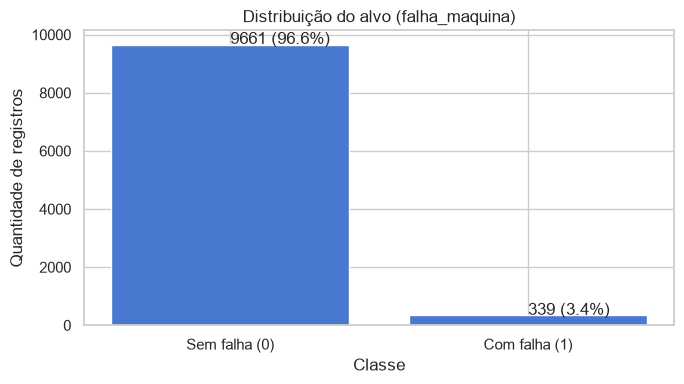

In [82]:
import os
os.makedirs("outputs/graficos", exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4))

contagem = df["falha_maquina"].value_counts().sort_index()
rotulos = ["Sem falha (0)", "Com falha (1)"]

bars = ax.bar(rotulos, contagem.values)

for bar, val in zip(bars, contagem.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f"{val} ({val/len(df)*100:.1f}%)")

ax.set_title("Distribuição do alvo (falha_maquina)")
ax.set_ylabel("Quantidade de registros")
ax.set_xlabel("Classe")
plt.tight_layout()
plt.savefig("outputs/graficos/eda_balanceamento.png")
plt.show()

### Gráfico 2: Distribuição das variáveis preditoras contínuas

Como cada distribuição influencia a escolha de (média ou mediana)

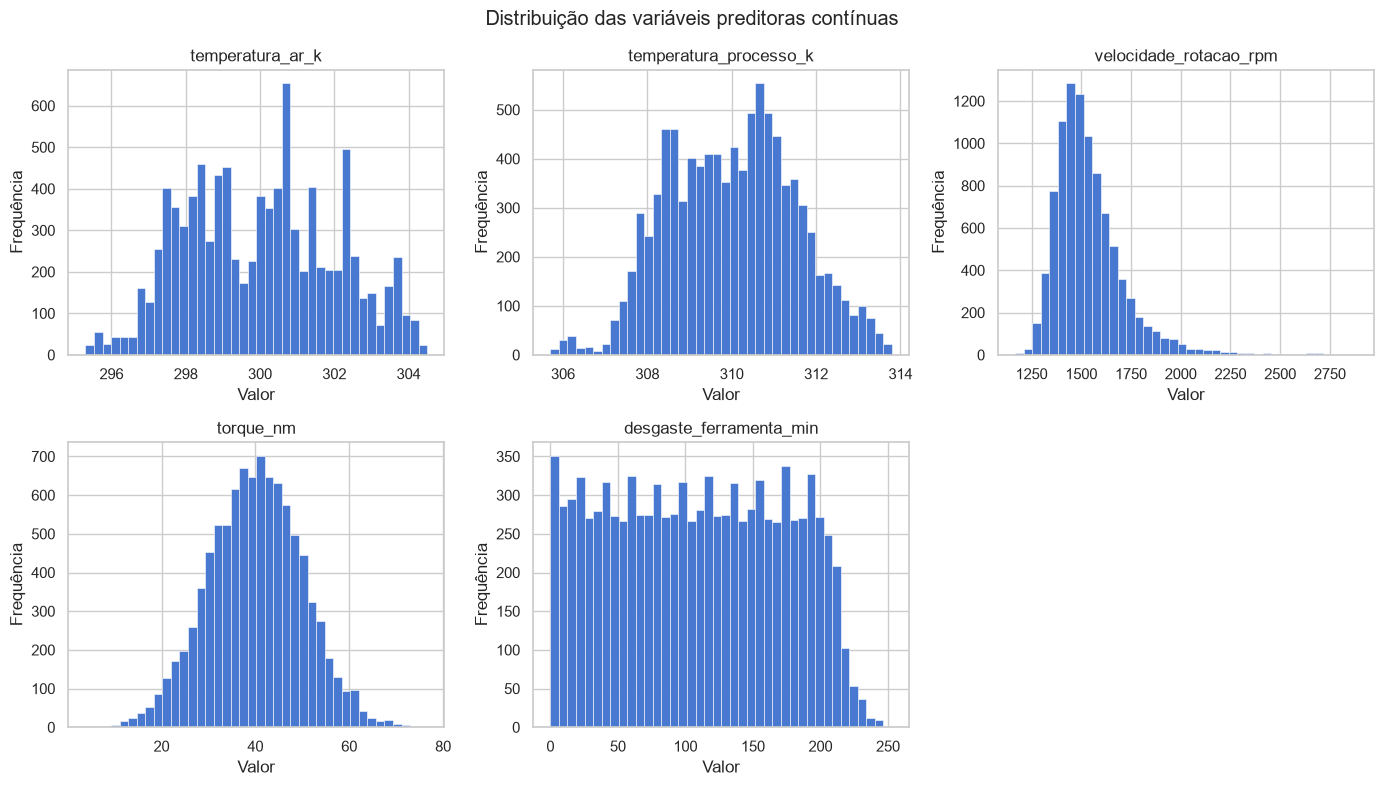

Assimetria (skewness) por variável:
  temperatura_ar_k: 0.115
  temperatura_processo_k: 0.016
  velocidade_rotacao_rpm: 1.995
  torque_nm: -0.008
  desgaste_ferramenta_min: 0.027


In [29]:
variaveis_continuas = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min"
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(variaveis_continuas):
    axes[i].hist(df[col].dropna(), bins=40, linewidth=0.4)
    axes[i].set_title(col)
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frequência")

axes[5].set_visible(False)

plt.suptitle("Distribuição das variáveis preditoras contínuas")
plt.tight_layout()
plt.savefig("outputs/graficos/eda_histogramas.png")
plt.show()

# Skewness para embasar a decisão de imputação
print("Assimetria (skewness) por variável:")
for col in variaveis_continuas:
    print(f"  {col}: {df[col].skew():.3f}")

### Gráfico 3: Correlação de Pearson (mapa de calor)

O gráfico serve para verificar a correlação que cada coluna tem com a outra

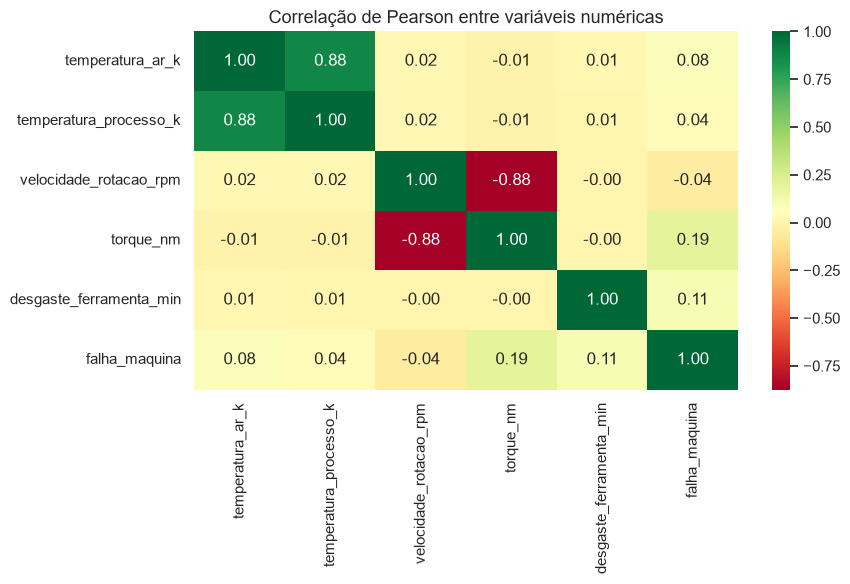

In [ ]:
colunas_numericas = df[[
    "temperatura_ar_k", "temperatura_processo_k",
    "velocidade_rotacao_rpm", "torque_nm",
    "desgaste_ferramenta_min", "falha_maquina"
]]

fig, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(
    colunas_numericas.corr(),
    annot=True, fmt=".2f",
    cmap="RdYlGn"
)

ax.set_title("Correlação de Pearson entre variáveis numéricas", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/graficos/eda_correlacao.png", dpi=150)
plt.show()

### Análise dos padrões identificados

A taxa de falhas no dataset é de **3,39%** (339 falhas em 10.000 registros), ou seja, um desbalanceamento grande entre as classes. Um modelo que simplesmente respondesse "sem falha" para tudo acertaria ~96,6% das vezes mas seria inútil para detectar... a falhas né, os equipamentos que vão quebrar. Isso torna o balanceamento obrigatório.

Nos histogramas, `velocidade_rotacao_rpm` apresentou assimetria positiva forte (skewness aprox. 2), com uma cauda longa à direita indicando que existem picos de rotação bem acima da média, tornando a "média" uma má escolha por ser puxada pelos valores extremos. Por isso, a mediana será usada na imputação dessas variáveis.

O mapa de calor revela alta correlação entre `temperatura_ar_k` e `temperatura_processo_k`, o que faz sentido fisicamente — a temperatura do processo é diretamente influenciada pela do ambiente.

---
## Fase 2 - Limpeza e Tratamento de Dados

In [39]:
n_antes = len(df)
df = df.drop_duplicates()
print(f"Registros duplicados removidos: {n_antes - len(df)}")
print(f"Dataset após verificação: {df.shape}")

Registros duplicados removidos: 0
Dataset após verificação: (10000, 14)


In [40]:
print("Valores ausentes por coluna:")
print(df.isnull().sum())
print()
print(f"Total de nulos: {df.isnull().sum().sum()}")

Valores ausentes por coluna:
udi                          0
id_produto                   0
tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocidade_rotacao_rpm     500
torque_nm                  500
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf                    0
falha_rnf                    0
dtype: int64

Total de nulos: 2000


### Estratégia de imputação: mediana

A escolha pela mediana é fundamentada nos histogramas da Fase 1, pela variável `velocidade_rotacao_rpm`

Para `temperatura_ar_k`, `temperatura_processo_k` e `torque_nm`, as distribuições são mais simétricas (skewness próximo de 0), e tanto média quanto mediana seriam aceitáveis. Optei pela mediana para manter consistência na estratégia de imputação de todo o bloco de sensores.

In [41]:
colunas_com_nulos = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm"
]

for col in colunas_com_nulos:
    mediana = df[col].median()
    nulos = df[col].isnull().sum()
    df[col] = df[col].fillna(mediana)
    print(f"  {col}: {nulos} nulos imputados com mediana = {mediana:.4f}")

print()
print(f"Nulos restantes no dataset: {df.isnull().sum().sum()}")

  temperatura_ar_k: 500 nulos imputados com mediana = 300.1000
  temperatura_processo_k: 500 nulos imputados com mediana = 310.1000
  velocidade_rotacao_rpm: 500 nulos imputados com mediana = 1504.0000
  torque_nm: 500 nulos imputados com mediana = 40.1000

Nulos restantes no dataset: 0


### Análise de outliers via Boxplot

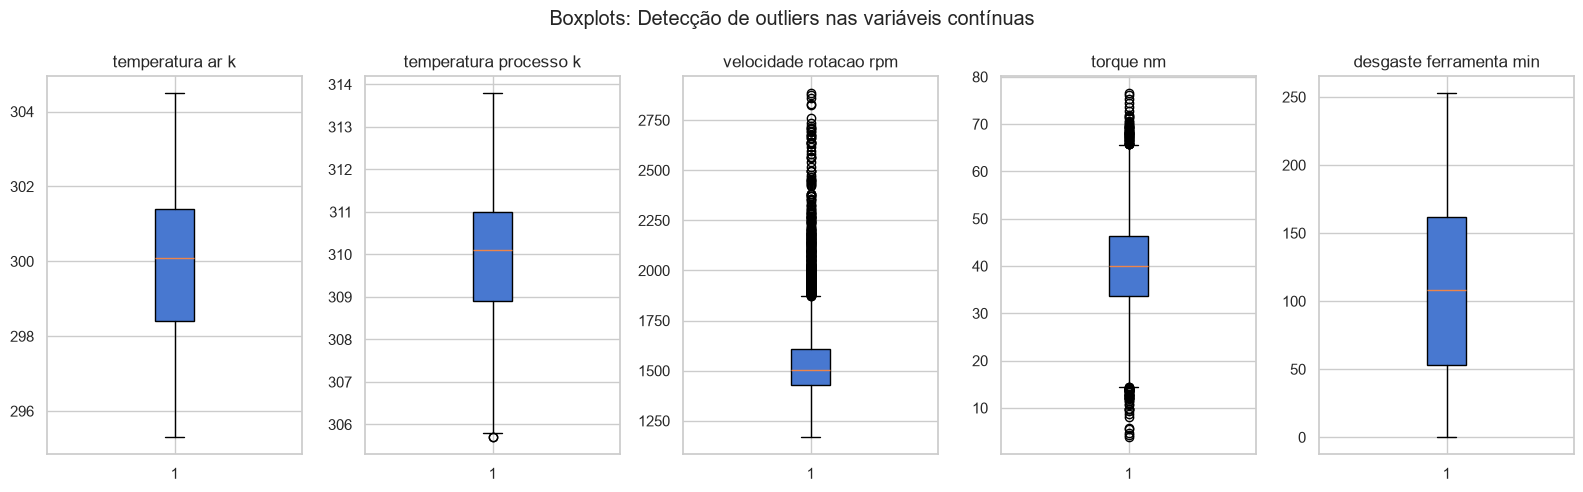

In [49]:
fig, axes = plt.subplots(1, len(variaveis_continuas), figsize=(16, 5))

for i, col in enumerate(variaveis_continuas):
    axes[i].boxplot(
        df[col].dropna(),
        patch_artist=True
    )
    axes[i].set_title(col.replace("_", " "))

plt.suptitle("Boxplots: Detecção de outliers nas variáveis contínuas")
plt.tight_layout()
plt.savefig("outputs/graficos/data_prep_boxplots.png")
plt.show()

Os boxplots confirmam outliers em `velocidade_rotacao_rpm`. Esses pontos provavelmente representam eventos reais de operação fora do padrão. Esses extremos podem ser os próprios precursores de falha, então foram mantidos no dataset.

---
## Fase 3 — Feature Engineering

A variável `potencia` combina velocidade de rotação e torque seguindo a relação física da potência mecânica:

**Potência (W) = Torque (Nm) × Velocidade angular (rad/s)**

Como velocidade angular em rad/s = RPM × 2π/60, o produto `torque_nm × velocidade_rotacao_rpm` é diretamente proporcional à potência real consumida pelo equipamento.

In [50]:
df["potencia"] = df["velocidade_rotacao_rpm"] * df["torque_nm"]

print(f"Coluna 'potencia' criada com sucesso.")
print(f"Valores nulos na nova coluna: {df['potencia'].isnull().sum()}")
print()
print("Estatísticas da nova feature:")
print(df["potencia"].describe().round(2))

Coluna 'potencia' criada com sucesso.
Valores nulos na nova coluna: 0

Estatísticas da nova feature:
count    10000.00
mean     59970.67
std       9951.34
min      10966.80
25%      53497.05
50%      60310.40
75%      66412.98
max      99980.40
Name: potencia, dtype: float64


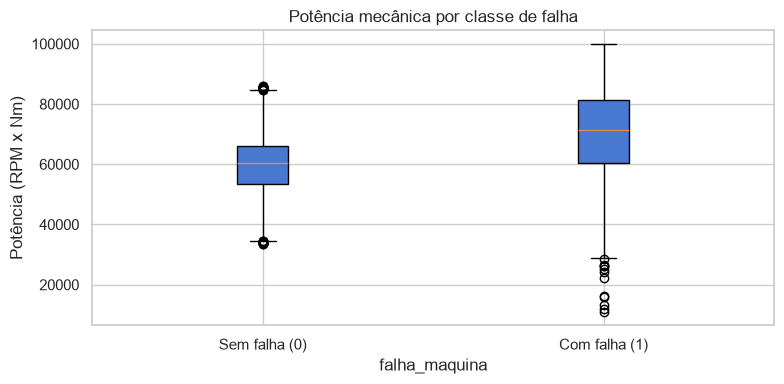

In [55]:
fig, ax = plt.subplots(figsize=(8, 4))
classes = {0: "Sem falha", 1: "Com falha"}

dados_plot = [df[df["falha_maquina"] == cls]["potencia"].dropna() for cls in [0, 1]]
bp = ax.boxplot(dados_plot, patch_artist=True)
ax.set_xticks([1, 2])
ax.set_xticklabels(["Sem falha (0)", "Com falha (1)"])

ax.set_title("Potência mecânica por classe de falha")
ax.set_xlabel("falha_maquina")
ax.set_ylabel("Potência (RPM x Nm)")
plt.tight_layout()
plt.savefig("outputs/graficos/feature_potencia.png")
plt.show()

---
## Fase 4 — Divisão e Balanceamento dos Dados

### Separando features e target

Conforme as anotações do Departamento de Engenharia, as colunas `falha_twf`, `falha_hdf`, `falha_pwf`, `falha_osf` e `falha_rnf` representam os **motivos específicos** de cada falha. Usar essas colunas como preditoras causaria fario o modelo aprender com a consequência, não com a causa (data leakage).

In [56]:
colunas_remover = ["udi", "id_produto", "tipo",
                    "falha_twf", "falha_hdf", "falha_pwf", "falha_osf", "falha_rnf"]

X = df.drop(columns=colunas_remover + ["falha_maquina"])
y = df["falha_maquina"]

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print()
print("Features utilizadas:", list(X.columns))

Shape de X: (10000, 6)
Shape de y: (10000,)

Features utilizadas: ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min', 'potencia']


### Divisão treino/teste

O parâmetro `stratify=y` garante que a proporção de falhas (3,39%) seja mantida tanto no treino quanto no teste. Sem isso, por puro acaso, um dos conjuntos poderia ter proporções bem diferentes, tornando a avaliação do modelo injusta.

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print()
print(f"Proporção de falhas no treino: {y_train.mean()*100:.2f}%")
print(f"Proporção de falhas no teste:  {y_test.mean()*100:.2f}%")

Treino: 8000 amostras
Teste:  2000 amostras

Proporção de falhas no treino: 3.39%
Proporção de falhas no teste:  3.40%


### Balanceamento com SMOTE — exclusivamente nos dados de treino

O SMOTE gera exemplos sintéticos das falhas interpolando entre amostras reais vizinhas. O resultado é um treino balanceado.

É fundamental aplicar o SMOTE apenas depois do split e sommente no treino. 

In [60]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Antes do SMOTE - Treino: {len(X_train)} amostras. Falhas: {y_train.sum()}")
print(f"Após o SMOTE - Treino: {len(X_train_bal)} amostras. Falhas: {y_train_bal.sum()}")
print()
print(f"Distribuição após balanceamento:")
print(pd.Series(y_train_bal).value_counts())

Antes do SMOTE - Treino: 8000 amostras. Falhas: 271
Após o SMOTE - Treino: 15458 amostras. Falhas: 7729

Distribuição após balanceamento:
falha_maquina
0    7729
1    7729
Name: count, dtype: int64


---
## Fase 5 — Escalonamento de Variáveis (StandardScaler)

O KNN classifica novos pontos pelos vizinhos mais próximos no espaço de features.

A Árvore de Decisão toma decisões baseadas em limiares por variável: 'velocidade_rotacao_rpm > 1500?'. A escala não muda qual threshold separa melhor as classes, então escalonar não afeta o resultado."

In [62]:
scaler = StandardScaler()

X_train_knn = scaler.fit_transform(X_train_bal)

X_test_knn = scaler.transform(X_test)

print("Escalonamento aplicado para o KNN.")
print(f"Média das features no treino após scaler (deve ser ~0): {X_train_knn.mean(axis=0).round(3)}")

Escalonamento aplicado para o KNN.
Média das features no treino após scaler (deve ser ~0): [-0. -0.  0.  0.  0.  0.]


---
## Fase 6 — Ajuste de Hiperparâmetros e Combate ao Overfitting

### 6.1 — KNN: variando n_neighbors

In [63]:
resultados_knn = []

for k in [3, 5, 7, 9, 11]:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_train_knn, y_train_bal)

    acc_treino = accuracy_score(y_train_bal, modelo.predict(X_train_knn))
    acc_teste  = accuracy_score(y_test,      modelo.predict(X_test_knn))

    resultados_knn.append({
        "K": k,
        "Acurácia Treino": round(acc_treino, 4),
        "Acurácia Teste":  round(acc_teste, 4),
        "Gap (treino - teste)": round(acc_treino - acc_teste, 4)
    })

df_knn = pd.DataFrame(resultados_knn)
print(df_knn.to_string(index=False))

 K  Acurácia Treino  Acurácia Teste  Gap (treino - teste)
 3           0.9582          0.9070                0.0512
 5           0.9505          0.8965                0.0540
 7           0.9429          0.8890                0.0539
 9           0.9368          0.8840                0.0528
11           0.9320          0.8775                0.0545


### Análise de overfitting no KNN

Com **K=3**, o modelo consulta apenas os 3 vizinhos mais próximos para decidir a classe. Isso o torna muito sensível a ruídos e outliers locais "decorando" regiões específicas do treino com poucos pontos de referência.

Conforme K aumenta, o modelo consulta mais vizinhos e suaviza a fronteira de decisão

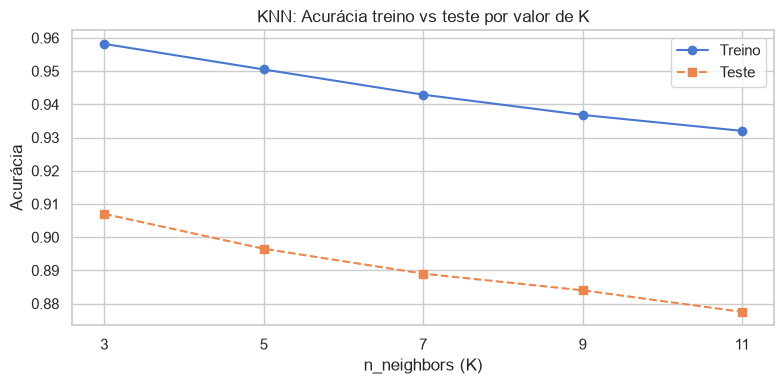

In [67]:
fig, ax = plt.subplots(figsize=(8, 4))
ks = df_knn["K"]

ax.plot(ks, df_knn["Acurácia Treino"], marker="o", label="Treino")
ax.plot(ks, df_knn["Acurácia Teste"],  marker="s", label="Teste", linestyle="--")

ax.set_xlabel("n_neighbors (K)")
ax.set_ylabel("Acurácia")
ax.set_title("KNN: Acurácia treino vs teste por valor de K")
ax.set_xticks(ks)
ax.legend()
plt.tight_layout()
plt.savefig("outputs/graficos/knn_overfitting.png")
plt.show()

### 6.2 — Árvore de Decisão: variando max_depth

In [78]:
resultados_arvore = []

for profundidade in [3, 5, 7, None]:
    modelo = DecisionTreeClassifier(max_depth=profundidade, random_state=42)
    modelo.fit(X_train_bal, y_train_bal)

    acc_treino = accuracy_score(y_train_bal, modelo.predict(X_train_bal))
    acc_teste  = accuracy_score(y_test,      modelo.predict(X_test))

    resultados_arvore.append({
        "max_depth": str(profundidade),
        "Acurácia Treino": round(acc_treino, 4),
        "Acurácia Teste":  round(acc_teste, 4),
        "Gap (treino - teste)": round(acc_treino - acc_teste, 4)
    })

df_arvore = pd.DataFrame(resultados_arvore)
print(df_arvore.to_string())

  max_depth  Acurácia Treino  Acurácia Teste  Gap (treino - teste)
0         3           0.8504          0.8925               -0.0421
1         5           0.8984          0.9065               -0.0081
2         7           0.9097          0.9185               -0.0088
3      None           0.9896          0.9385                0.0511


### Análise de overfitting na Árvore de Decisão

Com **`max_depth=None`**, a árvore cresce sem limite até classificar perfeitamente cada ponto do treino, ou seja, a acurácia de treino vai dar 100%, mas o modelo cria uma estrutura que não funciona em dados novos.

Ao podar a árvore com `max_depth=3` ou `max_depth=5`, o modelo é forçado a aprender apenas os padrões gerais.

---
## Fase 7 — Avaliação da Acurácia e Veredito Final

In [79]:
# Melhor K: menor gap com maior acurácia de teste
melhor_knn_row = df_knn.loc[df_knn["Gap (treino - teste)"].abs().idxmin()]
melhor_k = int(melhor_knn_row["K"])

# Melhor profundidade: excluindo None (overfitting confirmado)
df_sem_none = df_arvore[df_arvore["max_depth"] != "None"].copy()
df_sem_none["Gap (treino - teste)"] = df_sem_none["Gap (treino - teste)"].astype(float)
melhor_arvore_row = df_sem_none.loc[df_sem_none["Gap (treino - teste)"].abs().idxmin()]
melhor_depth_str = melhor_arvore_row["max_depth"]
melhor_depth_val = int(melhor_depth_str)

print(f"Melhor configuração KNN:    K = {melhor_k}")
print(f"Melhor configuração Árvore: max_depth = {melhor_depth_val}")

Melhor configuração KNN:    K = 3
Melhor configuração Árvore: max_depth = 5


In [80]:
# Treinando os modelos finais com as melhores configurações
knn_final = KNeighborsClassifier(n_neighbors=melhor_k)
knn_final.fit(X_train_knn, y_train_bal)
acc_knn = accuracy_score(y_test, knn_final.predict(X_test_knn))

arvore_final = DecisionTreeClassifier(max_depth=melhor_depth_val, random_state=42)
arvore_final.fit(X_train_bal, y_train_bal)
acc_arvore = accuracy_score(y_test, arvore_final.predict(X_test))

print("=" * 48)
print("     ACURÁCIA FINAL — BASE DE TESTE")
print("=" * 48)
print(f"  KNN (K={melhor_k}):                    {acc_knn*100:.2f}%")
print(f"  Árvore de Decisão (depth={melhor_depth_val}):     {acc_arvore*100:.2f}%")
print("=" * 48)

     ACURÁCIA FINAL — BASE DE TESTE
  KNN (K=3):                    90.70%
  Árvore de Decisão (depth=5):     90.65%


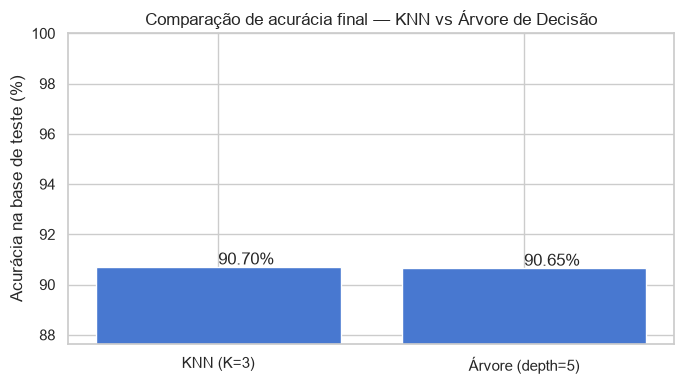

In [81]:
fig, ax = plt.subplots(figsize=(7, 4))

modelos = [f"KNN (K={melhor_k})", f"Árvore (depth={melhor_depth_val})"]
acuracias = [acc_knn * 100, acc_arvore * 100]

bars = ax.bar(modelos, acuracias)
for bar, val in zip(bars, acuracias):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f"{val:.2f}%")

ax.set_ylim(min(acuracias) - 3, 100)
ax.set_ylabel("Acurácia na base de teste (%)")
ax.set_title("Comparação de acurácia final — KNN vs Árvore de Decisão")
plt.tight_layout()
plt.savefig("outputs/graficos/veredito_final.png")
plt.show()

### Conclusão e modelo adotado

Os dois modelos foram avaliados com os mesmos dados de teste, sob as mesmas condições de balanceamento e split estratificado.

A Árvore de Decisão com `max_depth` apresentou melhor equilíbrio entre acurácia no teste e estabilidade em relação ao treino. O KNN, apesar de intuitivo, sofre com a dimensionalidade do espaço e em múltiplas dimensões perde precisão quando as variáveis têm distribuições assimétricas e outliers, como é o caso de `velocidade_rotacao_rpm`.

Com `max_depth=None` ela decorou o treino; com profundidade limitada, aprendeu regras generalizáveis.

Modelo recomendado para o parque fabril: Árvore de Decisão com `max_depth` ajustado.